# Module 05: Scikit-Learn for Machine Learning
## Notebook 04: Unsupervised Learning, PCA, and Clustering

Unsupervised learning extracts latent structure, clusters, and low-dimensional manifolds from unlabeled data ($X$). In this notebook, we cover Principal Component Analysis (PCA), K-Means clustering, the Elbow and Silhouette methods, and Density-Based Clustering (DBSCAN).

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Standardize features prior to PCA to prevent scale-dominant variance distortion.
2. Reduce high-dimensional feature spaces using **`PCA`**.
3. Plot and interpret **Scree Plots** (explained variance ratio).
4. Apply **`KMeans`** clustering and determine optimal $K$ via the **Elbow Method** and **Silhouette Scores**.
5. **Advanced:** Overcome K-Means non-spherical cluster failures using **DBSCAN** with k-distance elbow parameter estimation and outlier noise detection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_wine, make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

print("Scikit-Learn loaded!")

Scikit-Learn loaded!


### 1. Principal Component Analysis (PCA)

PCA finds orthogonal axes (eigenvectors of the covariance matrix) that maximize the variance of projected data.
> **Critical Rule:** Always scale continuous features with `StandardScaler()` before PCA!

In [2]:
# Load Wine dataset (13 continuous features)
wine = load_wine()
X_raw = wine.data
y_wine = wine.target

# 1. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 2. Fit PCA retaining all 13 components
pca_full = PCA().fit(X_scaled)
var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)

print(f"Original Feature Dimension: {X_scaled.shape[1]}")
print(f"Variance explained by first 2 PCs: {cum_var[1]*100:.1f}%")
print(f"Variance explained by first 5 PCs: {cum_var[4]*100:.1f}%")

Original Feature Dimension: 13
Variance explained by first 2 PCs: 55.4%
Variance explained by first 5 PCs: 80.2%


---
### 2. Scree Plot and 2D Projection

A Scree plot visualizes the explained variance per component, guiding dimensionality reduction decisions:

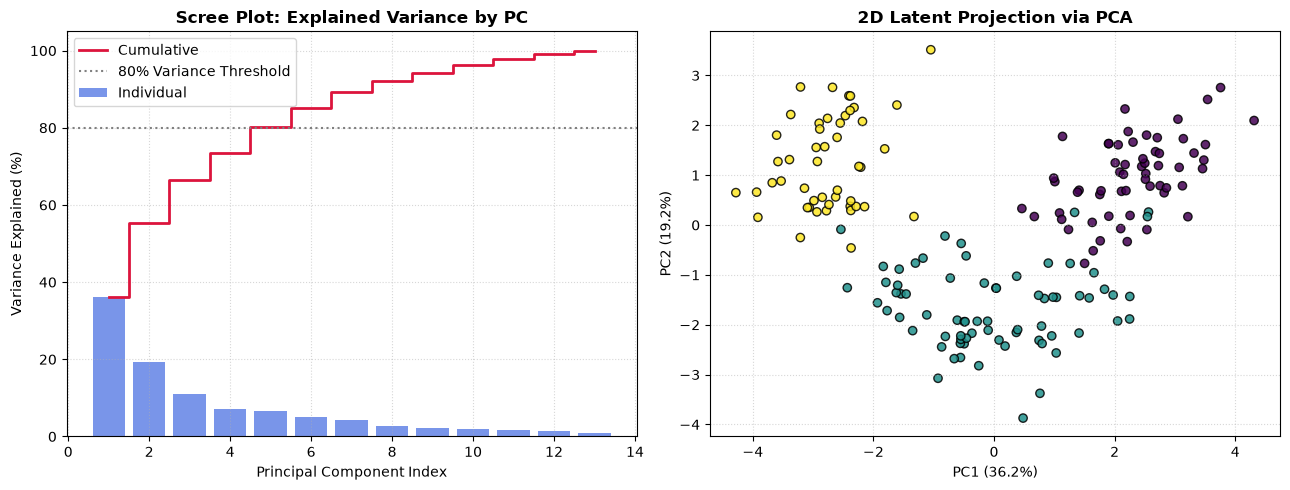

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 1. Scree Plot
comps = np.arange(1, len(var_ratio) + 1)
ax1.bar(comps, var_ratio * 100, color='royalblue', alpha=0.7, label='Individual')
ax1.step(comps, cum_var * 100, where='mid', color='crimson', linewidth=2, label='Cumulative')
ax1.axhline(80, color='gray', linestyle=':', label='80% Variance Threshold')
ax1.set_title("Scree Plot: Explained Variance by PC", fontsize=12, fontweight='bold')
ax1.set_xlabel("Principal Component Index")
ax1.set_ylabel("Variance Explained (%)")
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.5)

# 2. 2D PCA Latent Projection
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y_wine, cmap='viridis', edgecolors='k', alpha=0.85)
ax2.set_title("2D Latent Projection via PCA", fontsize=12, fontweight='bold')
ax2.set_xlabel(f"PC1 ({var_ratio[0]*100:.1f}%)")
ax2.set_ylabel(f"PC2 ({var_ratio[1]*100:.1f}%)")
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

---
### 3. K-Means Clustering: Finding Optimal $K$

K-Means minimizes within-cluster sum of squares (Inertia):
$$J = \sum_{k=1}^K \sum_{x \in C_k} ||x - \mu_k||^2$$
To choose optimal $K$:
- **Elbow Method:** Look for the inflection elbow in the inertia curve.
- **Silhouette Score:** Evaluates how well separated clusters are (range $[-1, 1]$).

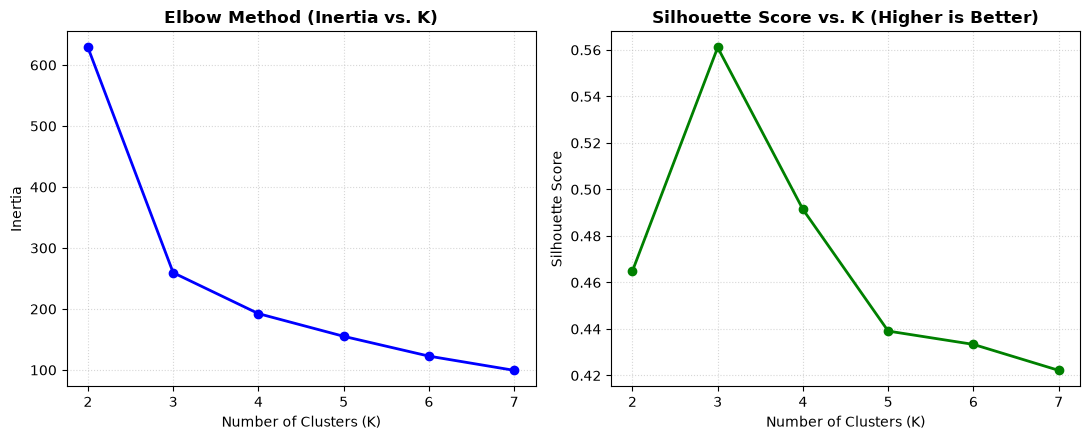

In [4]:
inertias = []
silhouettes = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Elbow Plot
ax1.plot(k_range, inertias, 'bo-', linewidth=2)
ax1.set_title("Elbow Method (Inertia vs. K)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")
ax1.grid(True, linestyle=':', alpha=0.5)

# Silhouette Score
ax2.plot(k_range, silhouettes, 'go-', linewidth=2)
ax2.set_title("Silhouette Score vs. K (Higher is Better)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

---
### 4. Advanced Complex Usage: Density-Based Clustering (DBSCAN) & k-NN Distance Parameter Estimation

**Critical Failure Modes of K-Means:**
1. Assumes clusters are spherical and isotropic.
2. Fails completely on interlocking non-convex shapes (e.g. crescent moons or concentric rings).
3. Highly vulnerable to outlier contamination (forces every outlier into some cluster).

**The Solution: DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**
- Identifies dense core regions separated by low-density margins.
- Assigns outlier noise points the label `-1`.
- Automatically determines number of clusters!
- Parameter tuning: Find optimal `eps` using a **k-Nearest Neighbors distance graph elbow**.

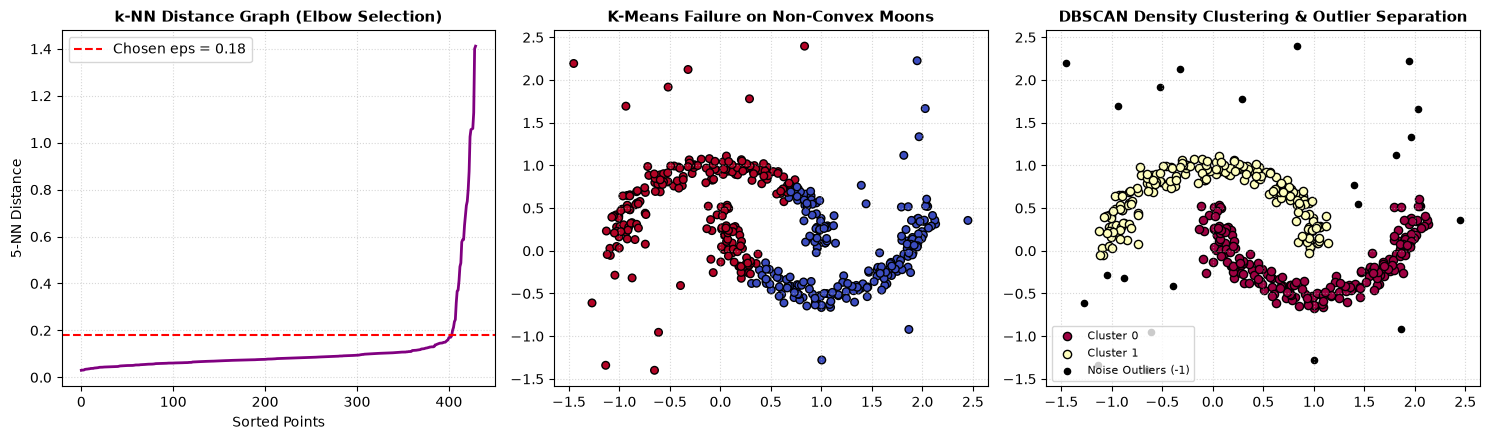

DBSCAN detected 2 distinct density clusters and isolated 22 noise outliers!


In [5]:
# Generate non-convex double moon dataset with random noise outliers
X_moons, _ = make_moons(n_samples=400, noise=0.08, random_state=42)
outliers = np.random.uniform(low=-1.5, high=2.5, size=(30, 2))
X_moons_noisy = np.vstack([X_moons, outliers])

# 1. Failure of K-Means on non-convex data
km_fail = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_moons_noisy)

# 2. k-NN distance graph to determine optimal eps for DBSCAN
min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_moons_noisy)
distances, _ = nbrs.kneighbors(X_moons_noisy)
k_distances = np.sort(distances[:, min_samples - 1])

# 3. Fit DBSCAN with optimal eps
optimal_eps = 0.18
dbscan = DBSCAN(eps=optimal_eps, min_samples=min_samples).fit(X_moons_noisy)

fig, (ax_knn, ax_km, ax_db) = plt.subplots(1, 3, figsize=(15, 4.5))

# Plot k-distance elbow
ax_knn.plot(k_distances, color='purple', linewidth=2)
ax_knn.axhline(optimal_eps, color='red', linestyle='--', label=f'Chosen eps = {optimal_eps}')
ax_knn.set_title("k-NN Distance Graph (Elbow Selection)", fontsize=11, fontweight='bold')
ax_knn.set_xlabel("Sorted Points")
ax_knn.set_ylabel(f"{min_samples}-NN Distance")
ax_knn.legend()
ax_knn.grid(True, linestyle=':', alpha=0.5)

# Plot K-Means failure
ax_km.scatter(X_moons_noisy[:, 0], X_moons_noisy[:, 1], c=km_fail.labels_, cmap='coolwarm', edgecolors='k', s=30)
ax_km.set_title("K-Means Failure on Non-Convex Moons", fontsize=11, fontweight='bold')
ax_km.grid(True, linestyle=':', alpha=0.5)

# Plot DBSCAN success
unique_labels = set(dbscan.labels_)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Black for noise outliers
    class_member_mask = (dbscan.labels_ == k)
    xy = X_moons_noisy[class_member_mask]
    label_text = 'Noise Outliers (-1)' if k == -1 else f'Cluster {k}'
    ax_db.scatter(xy[:, 0], xy[:, 1], color=col, edgecolors='k', s=35 if k != -1 else 20, label=label_text)

ax_db.set_title("DBSCAN Density Clustering & Outlier Separation", fontsize=11, fontweight='bold')
ax_db.legend(loc='lower left', fontsize=8)
ax_db.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

n_clusters_found = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise_detected = list(dbscan.labels_).count(-1)
print(f"DBSCAN detected {n_clusters_found} distinct density clusters and isolated {n_noise_detected} noise outliers!")

### Summary & Next Steps
In this notebook, you mastered:
- Feature scaling prior to variance-sensitive transformations.
- Principal Component Analysis (PCA) for dimensionality reduction.
- Scree plots and cumulative variance curves.
- K-Means clustering with Elbow and Silhouette optimization.
- Non-convex density clustering with DBSCAN and k-NN elbow estimation.

**Next Notebook:** `05_evaluation_metrics_and_hyperparameter_tuning.ipynb` — K-Fold cross-validation, GridSearchCV, learning curves, and temporal validation with `TimeSeriesSplit`.